# Linear regression model

Apply a linear regression model to predict the variable 'rate_avg'. Since the data can not be used as time series, we chose to consider the points as completely independent of time. Another choice could be to consider time series based on yearly division. 

Take aways from the EDA:

features that may have an importance: bedrooms, guest capacity, number of beds

features with minor importance: monthly price distribution, pool, gym, free parking, non-resident visitors, number of major events, temperature, rainfall

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
the_df=pd.read_csv('MSE446_cleaned_dataset_post_EDA.csv')
print(the_df.shape)
the_df.head()

(3225, 71)


,rate_avg,photos_count,superhost,latitude,longitude,guests,bedrooms,beds,baths,min_nights,...,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days,avg_temp
0,36.3,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,-3.925
1,35.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,0.770
2,35.9,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,7.040
3,36.0,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,13.890
4,36.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,19.470


In [3]:
mse_compare=[]
mae_compare=[]
mape_compare=[]
r2_compare=[]

WARNING: sklearn doesn't work with dates. Possible to replace date '2025-10-01' by 3 columns year/month/day. This approach could be used if decide to work with time series, but TEMPORARILY, decide to DROP the 'date' column.

## Idea:
Apply the following process with different types of feature selection:
1. split data
2. develop and fit the model
3. predict using the model + hyperparameter tuning with 5-fold CV
4. evaluate the model
5. bootstrap to get CI for coeffs and metrics
Types of feature selection to which the process above will be applied:
- baseline model including all features
- ridge regression
- lasso regression

## Baseline model

In [4]:
from sklearn.model_selection import train_test_split

X = the_df.drop(columns=['rate_avg']) #select all columns except 'rate_avg'
print(X.shape)
y=the_df['rate_avg']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=156)
print('\n'+str(X_train.shape))
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3225, 70)

(2580, 70)
(645, 70)
(2580,)
(645,)


In [5]:
# Create and fit the model
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

In [6]:
# Print the parameters of the model
print(lm.intercept_)
#print(lm.coef_)
coef_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print(coef_df)

7060.385391879683
                                          Coefficient
photos_count                                 0.061903
superhost                                   -6.472261
latitude                                    37.865214
longitude                                  112.203939
guests                                       7.503582
...                                               ...
cancellation_policy_Limited                 10.625904
cancellation_policy_Moderate               -15.040931
cancellation_policy_Strict                   2.608815
cancellation_policy_Super Strict 30 Days   -14.049422
avg_temp                                     0.691405

[70 rows x 1 columns]


MAE:  40.77202425784503
MSE:  3154.254595621845
MAPE:  0.4300878417846886
R^2:  0.7100929143100574


Text(0, 0.5, 'predicted rate_avg')

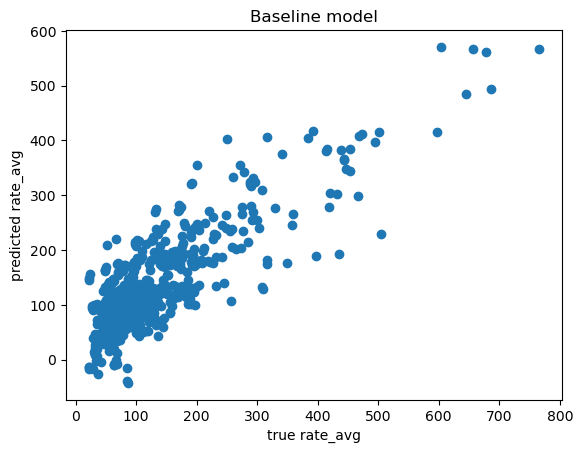

In [7]:
predictions = lm.predict(X_test)
#print('Predicted average price (rate_avg):', predictions)

from sklearn import metrics
#MAE: penalizes large errors
print('MAE: ', metrics.mean_absolute_error(y_test, predictions))
#MSE: direct representation of sum of error terms, 
print('MSE: ', metrics.mean_squared_error(y_test, predictions))
#MAPE: percentage of true value y, not use it if y = large variations and/or has 0 values
#'how far model is from actual values' <=> average relative error in %
print('MAPE: ', metrics.mean_absolute_percentage_error(y_test, predictions))

from sklearn.metrics import r2_score

print('R^2: ', r2_score(y_test, predictions))

mae_compare.append(metrics.mean_absolute_error(y_test, predictions))
mse_compare.append(metrics.mean_squared_error(y_test, predictions))
mape_compare.append(metrics.mean_absolute_percentage_error(y_test, predictions))
r2_compare.append(metrics.r2_score(y_test, predictions))

plt.scatter(y_test, predictions)
plt.title('Baseline model')
plt.xlabel('true rate_avg')
plt.ylabel('predicted rate_avg')

## Ridge regression

In [8]:
#delete same-named variables:
del X, y, X_train, X_test, y_train, y_test, predictions

Data split

In [9]:
from sklearn.model_selection import train_test_split

X = the_df.drop(columns=['rate_avg']) #select all columns except 'rate_avg'
print(X.shape)
y=the_df['rate_avg']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=156)
print('\n'+str(X_train.shape))
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3225, 70)

(2580, 70)
(645, 70)
(2580,)
(645,)


Fit model and hyperparameter tuning:

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

#scale features, initiate model, use GridSearchCV, search for the best penality alpha between 0.1 and 5
pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
params = {'ridge__alpha': np.linspace(0.1, 5, 100)}
grid_ridge = GridSearchCV(pipe, params, scoring='neg_mean_absolute_error', cv=5)
#Possible regression metrics to use:
#neg_mean_squared_error (MSE)
#neg_mean_absolute_error (MAE)
#r2 (R-squared)
grid_ridge.fit(X_train, y_train) #fit the function to train set 

# Find the best parameter and see how well it performs on test set
print(grid_ridge.best_params_)
best_scaler = grid_ridge.best_estimator_.named_steps['scaler']
best_alpha=float(grid_ridge.best_params_['ridge__alpha'])
print(grid_ridge.score(X_test, y_test))
#print(grid_ridge.cv_results_['mean_test_score'])

X_train_scaled = best_scaler.transform(X_train)
X_test_scaled  = best_scaler.transform(X_test)

{'ridge__alpha': 3.9606060606060614}
-40.76968131802209


results of the fit with the best alpha (penality coeff)

Evaluation:

MAE:  40.76968131802209
MSE:  3153.982628801015
MAPE:  0.4270051098836705
R^2:  0.7101179107413983
Max Error: 276.0933501642704
Median Absolute Error: 29.386804781601413


Text(0.5, 1.0, 'Q-Q Plot of Residuals')

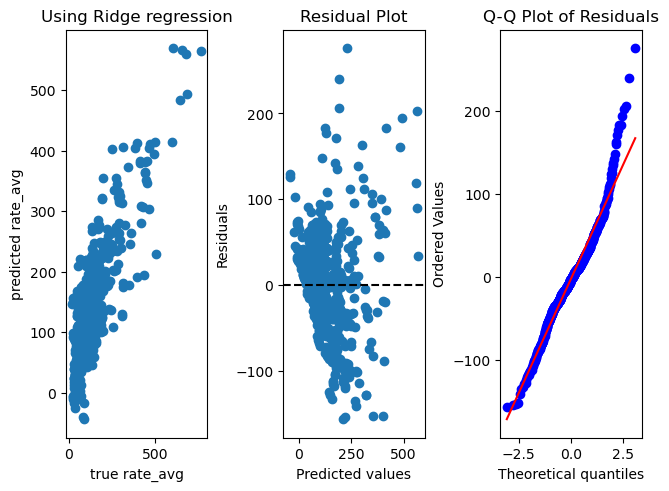

In [11]:
predict = grid_ridge.best_estimator_.predict(X_test)

from sklearn import metrics

print('MAE: ', metrics.mean_absolute_error(y_test, predict))
print('MSE: ', metrics.mean_squared_error(y_test, predict))
print('MAPE: ', metrics.mean_absolute_percentage_error(y_test, predict))
print('R^2: ', metrics.r2_score(y_test, predict))
print('Max Error:', metrics.max_error(y_test, predict))
print('Median Absolute Error:', metrics.median_absolute_error(y_test, predict)) #more robust to outliers than mean

mae_compare.append(metrics.mean_absolute_error(y_test, predict))
mse_compare.append(metrics.mean_squared_error(y_test, predict))
mape_compare.append(metrics.mean_absolute_percentage_error(y_test, predict))
r2_compare.append(metrics.r2_score(y_test, predict))

fig, axs=plt.subplots(1, 3, layout="constrained")
axs[0].scatter(y_test, predict)
axs[0].set_title('Using Ridge regression')
axs[0].set_xlabel('true rate_avg')
axs[0].set_ylabel('predicted rate_avg')

residuals = y_test - predict
axs[1].scatter(predict, residuals)
axs[1].axhline(0, linestyle='--', color='black')
axs[1].set_xlabel('Predicted values')
axs[1].set_ylabel('Residuals')
axs[1].set_title('Residual Plot')

import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axs[2])
axs[2].set_title('Q-Q Plot of Residuals') #values following red line = residuals are normally distributed (=assumption of lin reg)

#### Bootstrap
Bootstrap THE TRAINING SET to find confidence intervals and display the results

In [12]:
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

score_mse = []
score_mae = []
score_mape = []
score_r2 = []
n_iterations = 1000
coef_list = []

for i in range(n_iterations):
    # resample the TRAINING set, keep test set fixed
    X_boot, y_boot = resample(X_train_scaled, y_train, replace=True)
    
    #refit model on each bootstrap sample
    model_boot = Ridge(alpha=best_alpha)
    model_boot.fit(X_boot, y_boot)
    
    #evaluate on FIXED test set
    predict = model_boot.predict(X_test_scaled)
    curr_score_mse = mean_squared_error(y_test, predict, squared=True)  #MSE
    curr_score_mae = mean_absolute_error(y_test, predict) #MAE
    curr_score_mape = mean_absolute_percentage_error(y_test, predict) #MAPE
    curr_score_r2 = r2_score(y_test, predict) #R^2
    score_mse.append(curr_score_mse)
    score_mae.append(curr_score_mae)
    score_mape.append(curr_score_mape)
    score_r2.append(curr_score_r2)
    
    #collect coeffs
    coef_list.append(model_boot.coef_) 
    
coef_array = np.array(coef_list)  #shape: (1000, n_features)
for j, col in enumerate(X.columns):
    lo = np.percentile(coef_array[:, j], 2.5)
    hi = np.percentile(coef_array[:, j], 97.5)
    print(f'{col:30s}: 95% CI [{lo:.3f}, {hi:.3f}]')  #if CI crosses 0 --> unstable feature    
       
median_mse = np.median(score_mse)
lower_mse  = np.percentile(score_mse, 2.5)
upper_mse  = np.percentile(score_mse, 97.5)

median_mae = np.median(score_mae)
lower_mae  = np.percentile(score_mae, 2.5)
upper_mae  = np.percentile(score_mae, 97.5)

median_mape = np.median(score_mape)
lower_mape  = np.percentile(score_mape, 2.5)
upper_mape  = np.percentile(score_mape, 97.5)

median_r2 = np.median(score_r2)
lower_r2  = np.percentile(score_r2, 2.5)
upper_r2  = np.percentile(score_r2, 97.5)

#for coefficients (not for results):
#the further from 0 is the CI, the better
#the smaller the CI, the better
print(f'\nMedian MSE: {median_mse:.2f}, 95% CI: [{lower_mse:.2f}, {upper_mse:.2f}]')
print(f'Median MAE: {median_mae:.2f}, 95% CI: [{lower_mae:.2f}, {upper_mae:.2f}]')
print(f'Median MAPE: {median_mape:.2f}, 95% CI: [{lower_mape:.2f}, {upper_mape:.2f}]')
print(f'Median R^2: {median_r2:.2f}, 95% CI: [{lower_r2:.2f}, {upper_r2:.2f}]')

photos_count                  : 95% CI [-2.053, 5.164]
superhost                     : 95% CI [-5.391, -0.520]
latitude                      : 95% CI [-0.691, 6.262]
longitude                     : 95% CI [3.692, 8.429]
guests                        : 95% CI [6.811, 20.055]
bedrooms                      : 95% CI [32.098, 46.847]
beds                          : 95% CI [1.124, 9.287]
baths                         : 95% CI [22.991, 39.936]
min_nights                    : 95% CI [-19.174, -13.346]
cleaning_fee                  : 95% CI [8.104, 14.501]
extra_guest_fee               : 95% CI [-2.526, 0.506]
num_reviews                   : 95% CI [6.770, 11.409]
rating_overall                : 95% CI [62.459, 98.823]
rating_accuracy               : 95% CI [-44.272, -14.197]
rating_checkin                : 95% CI [-47.705, -14.309]
rating_cleanliness            : 95% CI [-15.403, 5.712]
rating_communication          : 95% CI [-3.880, 27.523]
rating_location               : 95% CI [22.503, 38.8

Text(0.5, 1.0, 'R^2')

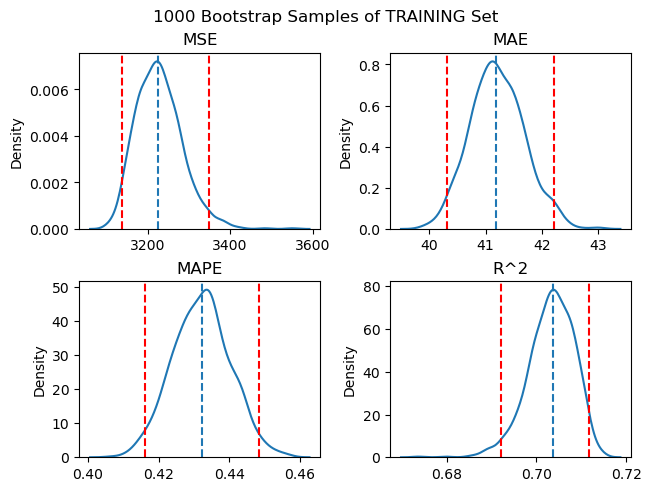

In [13]:
fig, axs = plt.subplots(2, 2, layout="constrained")
fig.suptitle('1000 Bootstrap Samples of TRAINING Set')
#MSE
sns.kdeplot(score_mse, ax=axs[0, 0])
axs[0, 0].axvline(median_mse, linestyle="--")
axs[0, 0].axvline(lower_mse, linestyle="--", color="red")
axs[0, 0].axvline(upper_mse, linestyle="--", color="red")
axs[0, 0].set_title('MSE')
#MAE
sns.kdeplot(score_mae, ax=axs[0, 1])
axs[0, 1].axvline(median_mae, linestyle="--")
axs[0, 1].axvline(lower_mae, linestyle="--", color="red")
axs[0, 1].axvline(upper_mae, linestyle="--", color="red")
axs[0, 1].set_title('MAE')
#MAPE
sns.kdeplot(score_mape, ax=axs[1, 0])
axs[1, 0].axvline(median_mape, linestyle="--")
axs[1, 0].axvline(lower_mape, linestyle="--", color="red")
axs[1, 0].axvline(upper_mape, linestyle="--", color="red")
axs[1, 0].set_title('MAPE')
#R^2
sns.kdeplot(score_r2, ax=axs[1, 1])
axs[1, 1].axvline(median_r2, linestyle="--")
axs[1, 1].axvline(lower_r2, linestyle="--", color="red")
axs[1, 1].axvline(upper_r2, linestyle="--", color="red")
axs[1, 1].set_title('R^2')

Text(0.5, 1.0, 'Coefficient estimates with 95% CI')

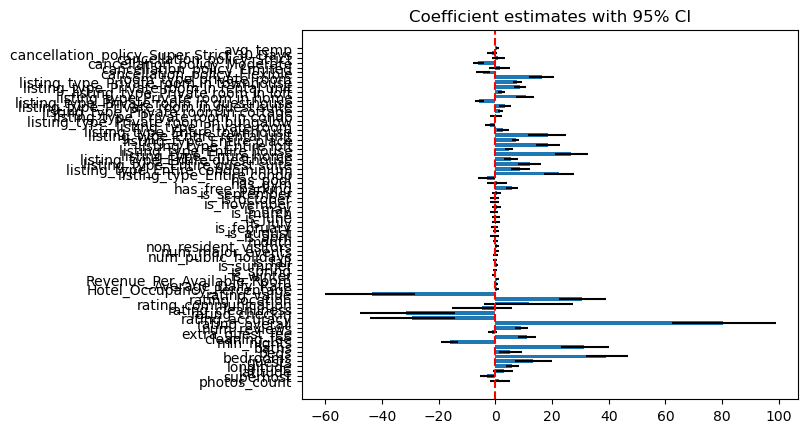

In [14]:
#coeff plot -->visualize bootstrap coefficient CIs
coef_array=np.array(coef_list)
means = coef_array.mean(axis=0)
lows  = np.percentile(coef_array,2.5,  axis=0)
highs = np.percentile(coef_array, 97.5, axis=0)

plt.barh(X.columns, means, xerr=[means-lows, highs-means])
plt.axvline(0, linestyle='--', color='red')
plt.title('Coefficient estimates with 95% CI')
#features whose CI crosses 0 = unstable/unreliable

Not necessary, but out of curiosity: CV learning curves: MAE vs amount of training data from the training set the model is allowed to see --> for training set error and validation set error

overfitting at beginning, then gets better

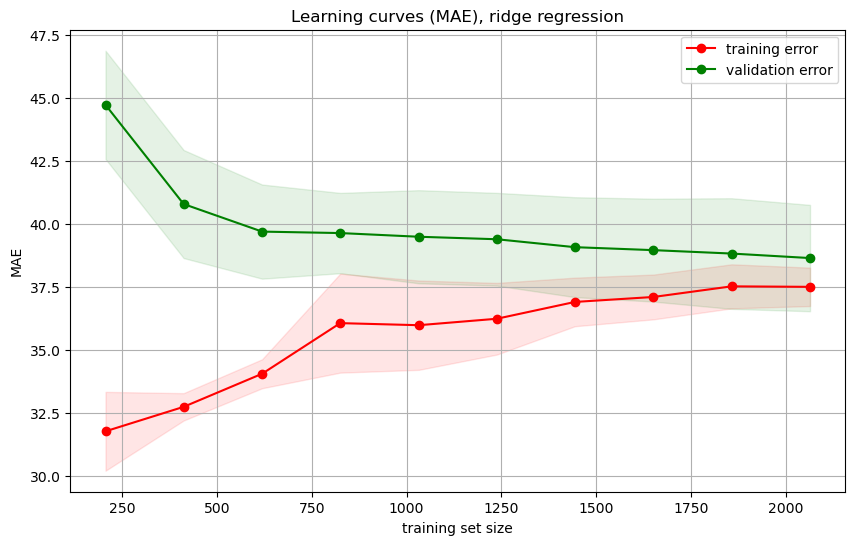

In [15]:
#CV learning curves: whether underfitting or overfitting + if more data would help
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    pipe, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_absolute_error', cv=5
)
train_errors = -train_scores.mean(axis=1)
val_errors = -val_scores.mean(axis=1)

train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_errors, 'o-', color="r", label="training error")
plt.plot(train_sizes, val_errors, 'o-', color="g", label="validation error")

plt.fill_between(train_sizes, train_errors - train_std, train_errors + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, val_errors - val_std, val_errors + val_std, alpha=0.1, color="g")

plt.title("Learning curves (MAE), ridge regression")
plt.xlabel("training set size")
plt.ylabel("MAE")
plt.legend(loc="best")
plt.grid(True)
plt.show()

## Lasso regression
Selects features --> puts some to 0

In [16]:
#HYPERPARAMETER TUNING to find best alpha
#see slide 37 ch.6

In [17]:
#delete same-named variables:
del X_train, X_test, y_train, y_test, coef_list, predict, coef_array

In [18]:
from sklearn.model_selection import train_test_split
 
X = the_df.drop(columns=['rate_avg']) #select all columns except 'rate_avg'
print(X.shape)
y = the_df['rate_avg']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156)
print('\n'+str(X_train.shape))
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3225, 70)

(2580, 70)
(645, 70)
(2580,)
(645,)


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso 
from sklearn.model_selection import GridSearchCV
 
# Scale features, initiate model, use GridSearchCV, search for the best penalty alpha
pipe = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(max_iter=100000))])  
#params = {'lasso__alpha': np.logspace(-3, 0, 10)}
params = {'lasso__alpha': np.linspace(0.035, 0.036, 10)}

# Possible regression metrics to use:
# neg_mean_squared_error (MSE)
# neg_mean_absolute_error (MAE)
# r2 (R-squared)
grid_lasso = GridSearchCV(pipe, params, scoring='neg_mean_absolute_error', cv=5)
grid_lasso.fit(X_train, y_train)
 
# Find the best parameter and see how well it performs on test set
print(grid_lasso.best_params_)
best_scaler = grid_lasso.best_estimator_.named_steps['scaler']
best_alpha = float(grid_lasso.best_params_['lasso__alpha'])
print(grid_lasso.score(X_test, y_test))
 
X_train_scaled = best_scaler.transform(X_train)
X_test_scaled  = best_scaler.transform(X_test)

#results:
#{'lasso__alpha': 0.046415888336127774}
#-40.75628578796824
#{'lasso__alpha': 0.035}
#-40.74154014859792
#{'lasso__alpha': 0.035555555555555556}
#-40.741929929187094
#{'lasso__alpha': 0.035666666666666666}
#-40.742007331418485
#{'lasso__alpha': 0.035666666666666666}
#-40.742007331418485
#{'lasso__alpha': 0.035666666666666666}
#-40.742007331418485

{'lasso__alpha': 0.035666666666666666}
-40.742007331418485


MAE:  40.742007331418485
MSE:  3154.115132740759
MAPE:  0.4277186461875539
R^2:  0.7101057323233761
Max Error: 275.8970374374409
Median Absolute Error: 29.482666080793976

Features put to 0 by Lasso (17): ['Hotel_Occupancy_Percentage', 'Revenue_Per_Available_Room', 'is_winter', 'is_spring', 'is_summer', 'is_fall', 'num_public_holidays', 'non_resident_visitors', 'is_august', 'is_february', 'is_july', 'is_june', 'is_november', 'is_september', 'listing_type_Private room in bungalow', 'listing_type_Private room in home', 'listing_type_Private room in loft']


Text(0.5, 1.0, 'Q-Q Plot of Residuals')

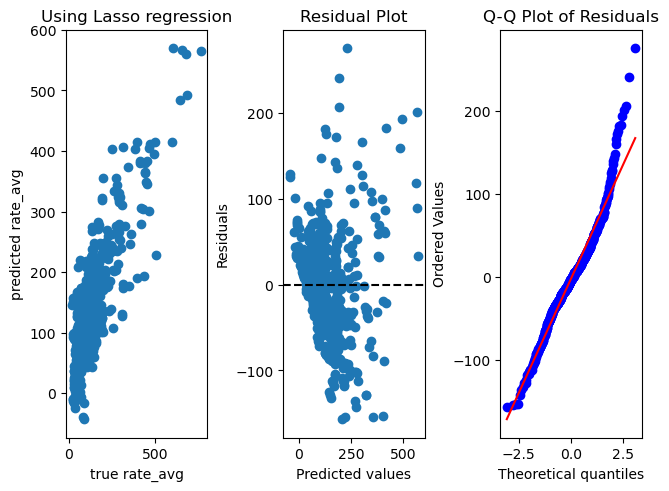

In [20]:
predict = grid_lasso.best_estimator_.predict(X_test)

from sklearn import metrics
 
print('MAE: ', metrics.mean_absolute_error(y_test, predict))
print('MSE: ', metrics.mean_squared_error(y_test, predict))
print('MAPE: ', metrics.mean_absolute_percentage_error(y_test, predict))
print('R^2: ', metrics.r2_score(y_test, predict))
print('Max Error:', metrics.max_error(y_test, predict))
print('Median Absolute Error:', metrics.median_absolute_error(y_test, predict))

mae_compare.append(metrics.mean_absolute_error(y_test, predict))
mse_compare.append(metrics.mean_squared_error(y_test, predict))
mape_compare.append(metrics.mean_absolute_percentage_error(y_test, predict))
r2_compare.append(metrics.r2_score(y_test, predict))

#show features that were put to 0 by lasso
lasso_coefs = grid_lasso.best_estimator_.named_steps['lasso'].coef_
zeroed = [col for col, coef in zip(X.columns, lasso_coefs) if coef == 0]
print(f'\nFeatures put to 0 by Lasso ({len(zeroed)}): {zeroed}')
 
fig, axs = plt.subplots(1, 3, layout="constrained")
axs[0].scatter(y_test, predict)
axs[0].set_title('Using Lasso regression')
axs[0].set_xlabel('true rate_avg')
axs[0].set_ylabel('predicted rate_avg')
 
residuals = y_test - predict
axs[1].scatter(predict, residuals)
axs[1].axhline(0, linestyle='--', color='black')
axs[1].set_xlabel('Predicted values')
axs[1].set_ylabel('Residuals')
axs[1].set_title('Residual Plot')
 
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axs[2])
axs[2].set_title('Q-Q Plot of Residuals')

In [21]:
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score
 
score_mse  = []
score_mae  = []
score_mape = []
score_r2   = []
n_iterations = 100
coef_list = []
 
for i in range(n_iterations):
    #resample the TRAINING set, keep test set fixed
    X_boot, y_boot = resample(X_train_scaled, y_train, replace=True)
 
    #refit model on each bootstrap sample
    model_boot = Lasso(alpha=best_alpha, max_iter=10000)
    model_boot.fit(X_boot, y_boot)
 
    #evaluate on FIXED test set
    predict_boot = model_boot.predict(X_test_scaled)
    score_mse.append(mean_squared_error(y_test, predict_boot, squared=True))
    score_mae.append(mean_absolute_error(y_test, predict_boot))
    score_mape.append(mean_absolute_percentage_error(y_test, predict_boot))
    score_r2.append(r2_score(y_test, predict_boot))
 
    #collect coefficients
    coef_list.append(model_boot.coef_)
 
coef_array = np.array(coef_list)  #shape:(1000,n_features)
for j, col in enumerate(X.columns):
    lo = np.percentile(coef_array[:, j], 2.5)
    hi = np.percentile(coef_array[:, j], 97.5)
    print(f'{col:30s}: 95% CI [{lo:.3f}, {hi:.3f}]')  # if CI crosses 0 --> unstable feature
 
median_mse = np.median(score_mse)
lower_mse  = np.percentile(score_mse, 2.5)
upper_mse  = np.percentile(score_mse, 97.5)
 
median_mae = np.median(score_mae)
lower_mae  = np.percentile(score_mae, 2.5)
upper_mae  = np.percentile(score_mae, 97.5)
 
median_mape = np.median(score_mape)
lower_mape  = np.percentile(score_mape, 2.5)
upper_mape  = np.percentile(score_mape, 97.5)
 
median_r2 = np.median(score_r2)
lower_r2  = np.percentile(score_r2, 2.5)
upper_r2  = np.percentile(score_r2, 97.5)
 
#for coefficients (not for results):
#the further from 0 the CI, the better
#the smaller the CI, the better
print(f'\nMedian MSE:  {median_mse:.2f},  95% CI: [{lower_mse:.2f},  {upper_mse:.2f}]')
print(f'Median MAE:  {median_mae:.2f},  95% CI: [{lower_mae:.2f},  {upper_mae:.2f}]')
print(f'Median MAPE: {median_mape:.2f}, 95% CI: [{lower_mape:.2f}, {upper_mape:.2f}]')
print(f'Median R^2:  {median_r2:.2f},  95% CI: [{lower_r2:.2f},  {upper_r2:.2f}]')

photos_count                  : 95% CI [-2.068, 4.443]
superhost                     : 95% CI [-5.479, -0.425]
latitude                      : 95% CI [-0.798, 5.632]
longitude                     : 95% CI [3.153, 8.029]
guests                        : 95% CI [6.221, 18.631]
bedrooms                      : 95% CI [33.110, 45.575]
beds                          : 95% CI [1.157, 9.852]
baths                         : 95% CI [24.814, 38.094]
min_nights                    : 95% CI [-18.670, -13.491]
cleaning_fee                  : 95% CI [7.624, 13.061]
extra_guest_fee               : 95% CI [-2.563, 0.204]
num_reviews                   : 95% CI [6.962, 11.626]
rating_overall                : 95% CI [73.235, 111.849]
rating_accuracy               : 95% CI [-49.082, -17.133]
rating_checkin                : 95% CI [-46.436, -15.399]
rating_cleanliness            : 95% CI [-18.261, 0.236]
rating_communication          : 95% CI [-5.163, 31.507]
rating_location               : 95% CI [21.153, 38.

Text(0.5, 1.0, 'R^2')

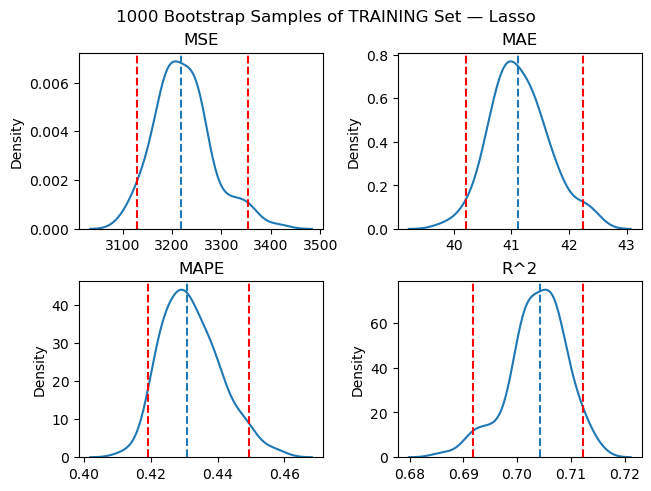

In [22]:
fig, axs = plt.subplots(2, 2, layout="constrained")
fig.suptitle('1000 Bootstrap Samples of TRAINING Set — Lasso')
# MSE
sns.kdeplot(score_mse, ax=axs[0, 0])
axs[0, 0].axvline(median_mse, linestyle="--")
axs[0, 0].axvline(lower_mse,  linestyle="--", color="red")
axs[0, 0].axvline(upper_mse,  linestyle="--", color="red")
axs[0, 0].set_title('MSE')
# MAE
sns.kdeplot(score_mae, ax=axs[0, 1])
axs[0, 1].axvline(median_mae, linestyle="--")
axs[0, 1].axvline(lower_mae,  linestyle="--", color="red")
axs[0, 1].axvline(upper_mae,  linestyle="--", color="red")
axs[0, 1].set_title('MAE')
# MAPE
sns.kdeplot(score_mape, ax=axs[1, 0])
axs[1, 0].axvline(median_mape, linestyle="--")
axs[1, 0].axvline(lower_mape,  linestyle="--", color="red")
axs[1, 0].axvline(upper_mape,  linestyle="--", color="red")
axs[1, 0].set_title('MAPE')
# R^2
sns.kdeplot(score_r2, ax=axs[1, 1])
axs[1, 1].axvline(median_r2, linestyle="--")
axs[1, 1].axvline(lower_r2,  linestyle="--", color="red")
axs[1, 1].axvline(upper_r2,  linestyle="--", color="red")
axs[1, 1].set_title('R^2')

Text(0.5, 1.0, 'Coefficient estimates with 95% CI')

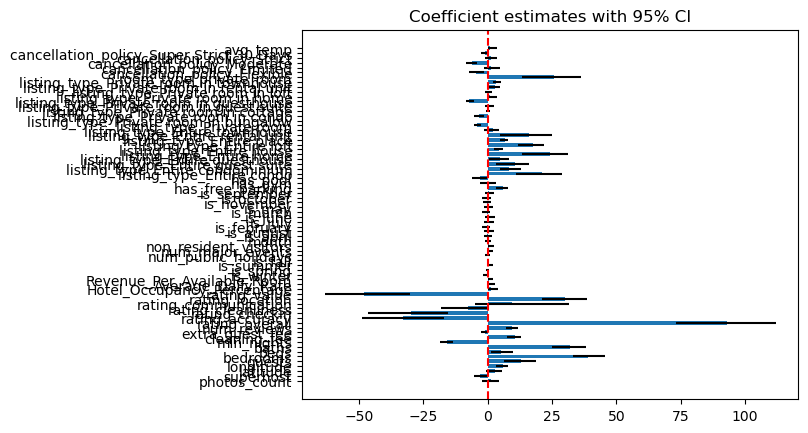

In [23]:
#coeff plot -->visualize bootstrap coefficient CIs
coef_array=np.array(coef_list)
means = coef_array.mean(axis=0)
lows  = np.percentile(coef_array,2.5,  axis=0)
highs = np.percentile(coef_array, 97.5, axis=0)

plt.barh(X.columns, means, xerr=[np.abs(means-lows), np.abs(highs-means)])
plt.axvline(0, linestyle='--', color='red')
plt.title('Coefficient estimates with 95% CI')
#features whose CI crosses 0 = unstable/unreliable

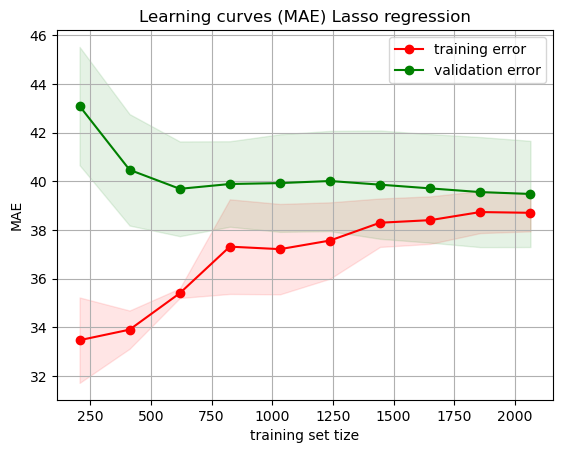

In [24]:
#CV learning curves: whether underfitting or overfitting + if more data would help
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(pipe, X_train, y_train,train_sizes=np.linspace(0.1, 1.0, 10),scoring='neg_mean_absolute_error', cv=5)
train_errors = -train_scores.mean(axis=1)
val_errors = -val_scores.mean(axis=1)

train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure()
plt.plot(train_sizes, train_errors, 'o-', color="r", label="training error")
plt.plot(train_sizes, val_errors, 'o-', color="g", label="validation error")
plt.fill_between(train_sizes, train_errors - train_std, train_errors + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, val_errors - val_std, val_errors + val_std, alpha=0.1, color="g")
plt.title("Learning curves (MAE) Lasso regression")
plt.xlabel("training set tize")
plt.ylabel("MAE")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [25]:
#Next stuff to do:
#compare the results side-by-side
results = {
    'Category':  ['Baseline', 'Ridge', 'Lasso'],   
    'MAE':       mae_compare,
    'MSE':       mse_compare,
    'MAPE':      mape_compare,
    'R^2':       r2_compare
}
df = pd.DataFrame(results).set_index('Category').T
df

Category,Baseline,Ridge,Lasso
MAE,40.772024,40.769681,40.742007
MSE,3154.254596,3153.982629,3154.115133
MAPE,0.430088,0.427005,0.427719
R^2,0.710093,0.710118,0.710106


### Notes

#### Feature selection

**Ridge:** keeps all features but stabilize the model, doesn't remove multicollinearity, but manages its damage to coefficients

**Lasso:** automatically picks one from a correlated pair and zero out the other, which one it picks can be arbitrary and unstable across runs/samples

**Forward/Backward selection:** worse* under multicollinearity because decision to include/exclude a feature changes depending on what else is already in the model --> not use it

K-fold CV: K=5-10 good

%who: Lists all variables currently in the global scope.

%whos: Shows a detailed table of variables (type, size, and content).